# Implement a New Clustering Algorithm: K-Medoids

<a href="https://colab.research.google.com/github/HassanAlgoz/dl/blob/main/modules/M0/01-clustering/sklearn_cluster_new_oop.ipynb" target="_blank">
  <img src="https://raw.githubusercontent.com/HassanAlgoz/dl/main/assets/Open%20in%20Colab-F9AB00.svg" alt="Open in Colab" height="50"/>
</a>

This is essentially a practical tutorial on **Object-oriented programming**.

In [ ]:
# --- Setup: Clone repo & cd into correct folder (for lab setup convenience) ---
import os
import subprocess

repo_url = "https://github.com/HassanAlgoz/dl.git"
lab_folder = "dl/modules/M0/01-clustering"

# Only clone if the folder doesn't exist
if not os.path.exists(lab_folder):
    subprocess.run(["git", "clone", repo_url])

# Change working directory to the lab folder
os.chdir(lab_folder)


## Learning Objectives

- Learn how algorithms are built with Python classes via object-oriented programming (OOP) and adapted to a specific library like scikit-learn.
- Connect OOP vocabulary to practice within scikit-learn models:
  - `__init__` for settings
  - `fit` for learning
  - trailing `_` for learned attributes
  - `predict` for reuse

## Context

We implement a **simplified** version of the alternate algorithm from [scikit-learn-extra's `KMedoids`](https://github.com/scikit-learn-contrib/scikit-learn-extra/blob/main/sklearn_extra/cluster/_k_medoids.py) (Park & Jun), which you can find in the docs here: [sklearn_extra.cluster.KMedoids](https://scikit-learn-extra.readthedocs.io/en/stable/generated/sklearn_extra.cluster.KMedoids.html).

In [1]:
# %pip install -qqq numpy pandas scikit-learn matplotlib seaborn

In [2]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import pairwise_distances

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

matplotlib.style.use("ggplot")

## Make Data

Three clear blobs in 2D — easy to see both cluster assignments and whether a center sits *on* a point or *between* points.

In [3]:
data, _ = make_blobs(n_samples=100, random_state=42, centers=3, cluster_std=1.5)

df = pd.DataFrame(data, columns=["x1", "x2"])
X = df.to_numpy()

df.head()

,x1,x2
0,-8.149818,-9.152380
1,5.860155,0.126873
2,-3.213409,9.828126
3,6.744070,-0.129607
4,-6.342946,-6.038933


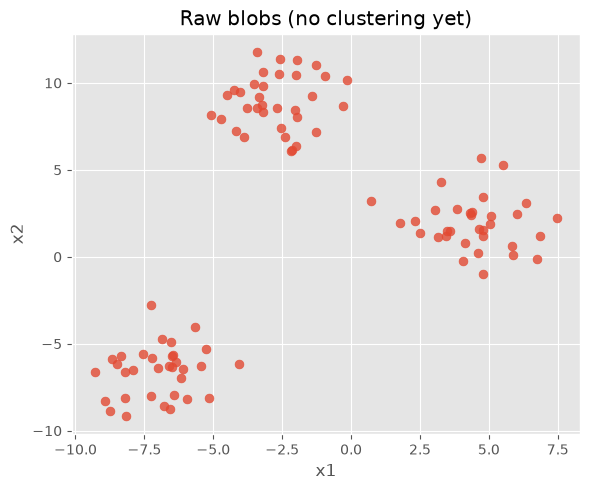

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df["x1"], df["x2"], s=40, alpha=0.8)
ax.set_title("Raw blobs (no clustering yet)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
plt.tight_layout()
plt.show()

## OOP in Practice: a Tiny Estimator

You have probably used code like:

```python
km = KMeans(n_clusters=3, random_state=42)
km.fit(X)
labels = km.labels_
```

That is object-oriented programming in everyday ML:

1. A **class** (`KMeans`) is the blueprint.
2. Creating an **instance** (`km = KMeans(...)`) stores *settings* (how many clusters, random seed, …).
3. Calling **`fit`** learns from data and stores results on the same object.
4. Attributes ending in **`_`** (like `labels_`) are the *learned* results — sklearn's naming convention.

Below we build our own `KMedoids` class the same way, so you can see *inside* the pattern instead of only calling a library.

### 1. `__init__` — store settings on the instance

`self` is "this particular k-medoids object." Anything we attach as `self.something` lives with that object until we overwrite it.

We only keep three knobs: how many clusters, how many update rounds to try, and a seed for reproducible random starts.

### 2. Private helpers — names that start with `_`

Methods starting with `_` are "for the class to use, not the main public API." We use them for:

- **Random init** — pick `n_clusters` distinct row indices as starting medoids.
- **Update medoids** — inside each cluster, choose the point with the smallest total distance to the other points in that cluster (the alternate step from sklearn-extra).
- **Inertia** — sum of each sample's distance to its nearest medoid.

### 3. `fit` — learn from data

Algorithm (assign → update → repeat):

1. Build the pairwise distance matrix `D` once.
2. Choose starting medoid indices.
3. Assign every point to the nearest medoid.
4. Recompute each cluster's medoid.
5. Stop when medoids stop changing (or we hit `max_iter`).

`fit` returns `self` so you can chain: `KMedoids(...).fit(X).labels_`.

### 4. `predict` — reuse what `fit` learned

New rows are labeled by nearest **stored** medoid (`cluster_centers_`). No re-training — that is the point of keeping state on the object.

In [5]:
class KMedoids:
    """Simplified k-medoids (alternate algorithm), for learning the sklearn OOP pattern.

    Parameters
    ----------
    n_clusters : int, default=8
        Number of clusters (and medoids) to form.
    max_iter : int, default=300
        Maximum number of assign/update rounds before stopping.
    random_state : int or None, default=None
        Seed for picking the initial medoids. Use an int for reproducible runs.
    """

    def __init__(self, n_clusters=8, max_iter=300, random_state=None):
        # Settings live on the instance — nothing learned yet.
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state

    def _initialize_medoids(self, n_samples):
        """Pick n_clusters distinct row indices at random.

        Parameters
        ----------
        n_samples : int
            Number of rows in X (upper bound for index choices).

        Returns
        -------
        medoid_idxs : ndarray of shape (n_clusters,)
            Starting medoid row indices into X.
        """
        rng = np.random.RandomState(self.random_state)
        return rng.choice(n_samples, size=self.n_clusters, replace=False)

    def _update_medoids(self, D, labels, medoid_idxs):
        """For each cluster, replace the medoid with the best member point.

        "Best" = smallest sum of distances to every other point in the same cluster.

        Parameters
        ----------
        D : ndarray of shape (n_samples, n_samples)
            Pairwise distances between all training points.
        labels : ndarray of shape (n_samples,)
            Current cluster id for each point (0 .. n_clusters-1).
        medoid_idxs : ndarray of shape (n_clusters,)
            Current medoid row indices; updated in place.
        """
        for k in range(self.n_clusters):
            members = np.where(labels == k)[0]
            if len(members) == 0:
                continue  # empty cluster — leave this medoid alone

            # Distances only among points currently in cluster k
            in_cluster = D[np.ix_(members, members)]
            costs = in_cluster.sum(axis=1)
            best = members[np.argmin(costs)]
            medoid_idxs[k] = best

    def _compute_inertia(self, D, medoid_idxs):
        """Sum of each point's distance to its nearest medoid.

        Parameters
        ----------
        D : ndarray of shape (n_samples, n_samples)
            Pairwise distances between all training points.
        medoid_idxs : ndarray of shape (n_clusters,)
            Row indices of the current medoids.

        Returns
        -------
        inertia : float
            Total distance from every point to its closest medoid.
        """
        return np.min(D[:, medoid_idxs], axis=1).sum()

    def fit(self, X):
        """Learn medoids and labels from X. Store results as attributes ending in _.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Training data to cluster.

        Returns
        -------
        self : KMedoids
            The fitted instance (supports chaining: `.fit(X).labels_`).

        Attributes set
        --------------
        medoid_indices_ : ndarray of shape (n_clusters,)
            Row indices of the chosen medoids in X.
        cluster_centers_ : ndarray of shape (n_clusters, n_features)
            The medoid rows themselves (real points from X).
        labels_ : ndarray of shape (n_samples,)
            Cluster assignment for each training row.
        inertia_ : float
            Sum of distances to the nearest medoid.
        """
        X = np.asarray(X, dtype=float)
        n_samples = X.shape[0]

        # All pairwise distances — used for assign + update steps
        D = pairwise_distances(X)

        medoid_idxs = self._initialize_medoids(n_samples)

        for _ in range(self.max_iter):
            old = medoid_idxs.copy()

            # Assign: each column of D[medoids] is one sample's distances to medoids
            labels = np.argmin(D[medoid_idxs, :], axis=0)

            self._update_medoids(D, labels, medoid_idxs)

            if np.array_equal(old, medoid_idxs):
                break  # converged

        # Learned attributes (trailing underscore = sklearn convention)
        self.medoid_indices_ = medoid_idxs
        self.cluster_centers_ = X[medoid_idxs]  # real rows of X
        self.labels_ = np.argmin(D[medoid_idxs, :], axis=0)
        self.inertia_ = self._compute_inertia(D, medoid_idxs)

        return self  # enables chaining: .fit(X).labels_

    def predict(self, X):
        """Assign new samples to the nearest learned medoid.

        Parameters
        ----------
        X : array-like of shape (n_query, n_features)
            New data to label. Must have the same number of features as training X.

        Returns
        -------
        labels : ndarray of shape (n_query,)
            Predicted cluster id for each row (nearest medoid).
        """
        X = np.asarray(X, dtype=float)
        distances = pairwise_distances(X, self.cluster_centers_)
        return np.argmin(distances, axis=1)

## Use It

Same API shape as `KMeans`: construct → `fit` → read `labels_` / `cluster_centers_`.

In [6]:
kmedoids = KMedoids(n_clusters=3, random_state=41)
kmedoids.fit(X)

print("Medoid row indices:", kmedoids.medoid_indices_)
print("Inertia:", round(kmedoids.inertia_, 2))
print("First 10 labels:", kmedoids.labels_[:10])

Medoid row indices: [21 41 51]
Inertia: 176.52
First 10 labels: [0 2 1 2 0 2 1 2 2 1]


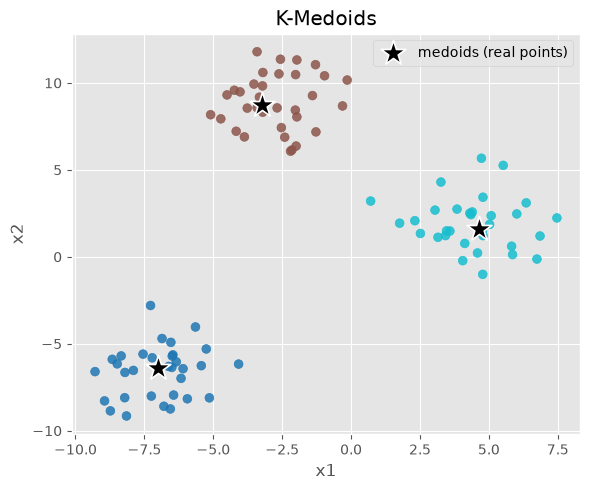

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df["x1"], df["x2"], c=kmedoids.labels_, cmap="tab10", s=40, alpha=0.85)
ax.scatter(
    kmedoids.cluster_centers_[:, 0],
    kmedoids.cluster_centers_[:, 1],
    marker="*",
    s=350,
    c="black",
    edgecolors="white",
    linewidths=1.2,
    label="medoids (real points)",
    zorder=5,
)
ax.set_title("K-Medoids")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

Notice each star sits **on top of a data point**. That is the medoid: a member of the dataset, not an average floating in empty space.

## Contrast with K-Means

Same data, same `k`. K-means centers can land *between* points; k-medoids centers are always observations.

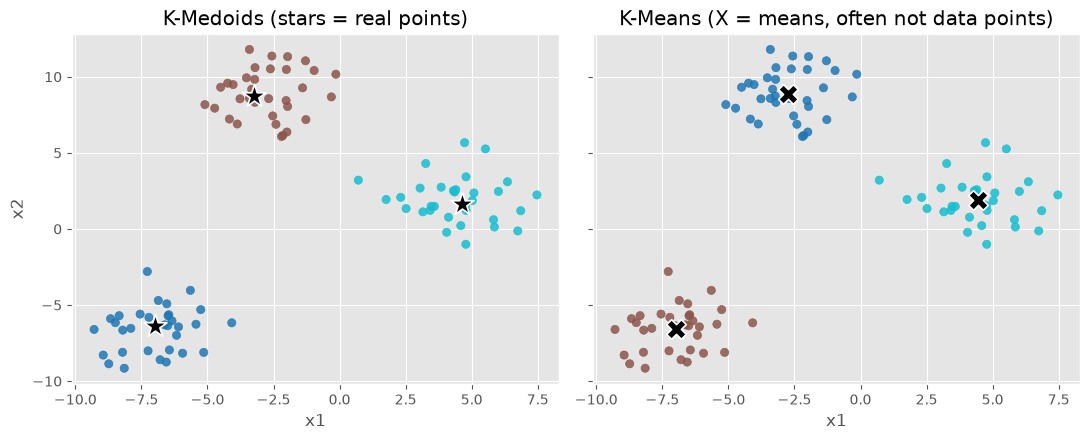

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)

axes[0].scatter(df["x1"], df["x2"], c=kmedoids.labels_, cmap="tab10", s=35, alpha=0.85)
axes[0].scatter(
    kmedoids.cluster_centers_[:, 0],
    kmedoids.cluster_centers_[:, 1],
    marker="*",
    s=300,
    c="black",
    edgecolors="white",
    linewidths=1.2,
    zorder=5,
)
axes[0].set_title("K-Medoids (stars = real points)")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")

axes[1].scatter(df["x1"], df["x2"], c=kmeans.labels_, cmap="tab10", s=35, alpha=0.85)
axes[1].scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    c="black",
    edgecolors="white",
    linewidths=1.2,
    zorder=5,
)
axes[1].set_title("K-Means (X = means, often not data points)")
axes[1].set_xlabel("x1")

plt.tight_layout()
plt.show()

## OOP Recap

You just used the same shape as scikit-learn estimators:

| Idea | In our class |
|------|----------------|
| Class / blueprint | `class KMedoids` |
| Instance settings | `self.n_clusters`, `self.max_iter`, `self.random_state` in `__init__` |
| Learn from data | `fit(X)` |
| Learned results (`_`) | `labels_`, `medoid_indices_`, `cluster_centers_`, `inertia_` |
| Helpers (internal) | `_initialize_medoids`, `_update_medoids`, `_compute_inertia` |
| Method chaining | `return self` from `fit` |
| Reuse without retraining | `predict(X_new)` using `cluster_centers_` |

That is why `KMeans(n_clusters=3).fit(X).labels_` feels natural: construct with settings, fit to learn, read trailing-underscore attributes.